# Reto 4 — Deep Q-Learning aplicado a **Snake**
### Reproducir, diagnosticar y corregir un proyecto de RL publicado

**Maestría en Ciencia de Datos y Analítica — Universidad EIA**
**Curso:** Aprendizaje por Refuerzo
**Autor:** Simón Garcés
**Modalidad:** Proyecto libre

---

## De qué se trata este trabajo

El enunciado del reto es *libre*: tomar un proyecto de RL, ejecutarlo y concluir. Elegí el
proyecto **Snake-Pygame-DQN** del repositorio de Rafael Stekolshchik
([enlace al commit exacto](https://github.com/Rafael1s/Deep-Reinforcement-Learning-Algorithms/tree/85b1148de13cd5a2a46cce016412f783163e50a0/Snake-Pygame-DQN)),
que entrena una serpiente a jugar Snake con una red Q.

**Todo el código de `snake_dqn/` es del autor original, no mío** (ver
[`snake_dqn/ATTRIBUTION.md`](snake_dqn/ATTRIBUTION.md)). Mi aporte es este notebook: el
análisis, el diagnóstico, las correcciones y las conclusiones.

## Por qué este proyecto resultó ser una buena elección

La intención inicial era simplemente *correrlo y reportar*. Al intentarlo aparecieron cuatro
hallazgos que convirtieron el trabajo en algo bastante más interesante que una reproducción:

| # | Hallazgo | Sección |
|---|---|---|
| 1 | **El código publicado no corre**: hay un `NameError` en el bucle de entrenamiento | §4 |
| 2 | **No es DQN**: le falta la *red objetivo*, que es precisamente lo que define a DQN | §5 |
| 3 | **Reproducirlo cuesta ~19 h de CPU**, no las "50.000 épocas" que sugiere el README | §6 |
| 4 | **El autor sub-reporta su propio agente en ~50%** por medir con exploración activada | §7 |

### Los dos hallazgos centrales

**El repositorio no implementa DQN (§5).** Se llama `Snake-Pygame-DQN` y su README habla de DQN,
pero el algoritmo es **Q-learning con memoria de repetición**: falta la red objetivo congelada que
introdujeron Mnih et al. (2015), y el objetivo TD ni siquiera está desconectado del grafo de
gradientes. Lo demuestro con código, implemento la versión correcta y **comparo ambas
empíricamente** con presupuesto de cómputo idéntico.

**El autor mide mal su propio resultado (§7).** Su README reporta una longitud media de **18**.
Al cargar sus pesos publicados y evaluarlos con política puramente *greedy*, la longitud media
real es **~27**: un 50% más. La causa es que sus cifras se toman **durante el entrenamiento con
$\varepsilon = 0{,}1$**, es decir con un 10% de acciones aleatorias contaminando la medición. Es
un error de método que va en dirección contraria a la habitual —normalmente se *sobre*-reporta— y
deja ver por qué las métricas de entrenamiento y las de evaluación nunca deben confundirse.

> Ambos hallazgos apuntan a la misma moraleja: **reproducir un trabajo publicado no es descargarlo
> y ejecutarlo**. Es leerlo con suficiente cuidado como para encontrar en qué se equivocó.

## Estructura

1. Preparación del entorno
2. El juego de Snake como Proceso de Decisión de Markov
3. Anatomía del código original (estado, acciones, recompensas)
4. **Diagnóstico 1** — el código publicado no ejecuta
5. **Diagnóstico 2** — esto no es DQN
6. Presupuesto de cómputo: cuánto cuesta reproducir el resultado original
7. Evaluación de los *checkpoints* entrenados por el autor
8. Entrenamiento A — línea base (diseño original, solo con el bug corregido)
9. Entrenamiento B — DQN real (red objetivo, `detach`, Huber, ε decreciente)
10. Comparación de A contra B
11. Ver al agente jugar
12. Discusión: qué funcionó, qué no
13. Respuestas a las preguntas guía
14. Resumen ejecutivo

## 1. Preparación del entorno

El notebook vive en `challenges/Reto4_ProyectoLibre/submission/` y el código original está en
la subcarpeta `snake_dqn/`. Añadimos esa carpeta al `sys.path` para poder importar los módulos
del autor **sin modificarlos ni moverlos** — es importante que queden intactos, porque parte del
trabajo consiste en comparar contra ellos.

In [1]:
import sys, os, time, random
from pathlib import Path

# Carpeta con el codigo original del autor (no se modifica en ningun momento)
UPSTREAM_DIR = Path.cwd() / "snake_dqn"
assert UPSTREAM_DIR.exists(), f"No encuentro {UPSTREAM_DIR}. Ejecuta el notebook desde su propia carpeta."
if str(UPSTREAM_DIR) not in sys.path:
    sys.path.insert(0, str(UPSTREAM_DIR))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Modulos del autor original
from Game import GameEnvironment, snakeclass, appleclass
from model import QNetwork, get_network_input
from replay_buffer import ReplayMemory

# Semilla global: fija inicializacion de la red y exploracion (ver seccion 10.2 sobre su alcance)
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("Python  ", sys.version.split()[0])
print("PyTorch ", torch.__version__)
print("NumPy   ", np.__version__)
print("Hilos   ", torch.get_num_threads())
print("Upstream", UPSTREAM_DIR)

Python   3.12.9
PyTorch  2.13.0+cpu
NumPy    2.4.6
Hilos    6
Upstream c:\rl-course_EIA_20262\challenges\Reto4_ProyectoLibre\submission\snake_dqn


> **Cómo funciona.** `sys.path.insert` antepone la carpeta `snake_dqn/` a la lista de rutas donde
> Python busca módulos, de modo que `from Game import GameEnvironment` encuentra el archivo del
> autor. Es la alternativa limpia a copiar sus archivos junto al notebook: el código original
> queda en su propia carpeta, claramente separado y atribuido.
>
> La semilla se fija en `random`, `numpy` **y** `torch` porque el proyecto usa las tres fuentes de
> aleatoriedad: `numpy` genera la posición de las manzanas, `random` muestrea el *replay buffer* y
> `torch` inicializa los pesos de la red.

## 2. Snake como Proceso de Decisión de Markov

Antes de tocar el código conviene escribir el problema en el lenguaje del curso:
$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$.

El tablero es una cuadrícula de $15 \times 15$. La serpiente avanza una casilla por paso en la
dirección actual; el agente solo decide **si gira**. Come manzanas para crecer y muere si choca
contra un borde o contra su propio cuerpo.

### 2.1 Estado $s_t$ — qué observa el agente

El autor **no** usa la imagen del tablero (como hace el paper original de Atari), sino un vector
compacto de **10 números**:

$$s_t = \big[\underbrace{x_{\text{cabeza}},\, y_{\text{cabeza}}}_{2},\ \underbrace{x_{\text{manzana}},\, y_{\text{manzana}}}_{2},\ \underbrace{d_x,\, d_y}_{2},\ \underbrace{p_L,\, p_R,\, p_U,\, p_D}_{4}\big]$$

donde $(d_x, d_y)$ es el vector de dirección actual y $p_i \in \{0,1\}$ indica si morir es
inmediato al moverse hacia el lado $i$ (*proximity*: el "sensor de peligro" de la serpiente).

> **Observación crítica para más adelante.** Las posiciones son **absolutas**, no relativas. El
> agente recibe "cabeza en (7,7), manzana en (10,1)" en vez de "la manzana está 3 a la derecha y
> 6 arriba". Esto lo obliga a aprender por separado cada combinación de posiciones en el tablero,
> en lugar de aprender la regla general *acércate a la manzana*. Volveremos a esto en §12.

### 2.2 Acciones $\mathcal{A}$

$$a_t \in \{0, 1, 2, 3, 4\}$$

El README del autor documenta **cuatro**: `0` izquierda, `1` derecha, `2` arriba, `3` abajo. Pero
la red tiene **cinco** salidas (`output_dim=5`) y la exploración muestrea `randint(0, 5)`. La
acción `4` no aparece en ningún `if` de `update_boardstate`, así que equivale a *seguir recto*:
un no-op no documentado. Lo verificamos en §3.

Además, los giros de 180° están prohibidos: si la serpiente va a la derecha, la acción "izquierda"
se ignora (no puede devolverse sobre su propio cuello).

### 2.3 Recompensa $r_t$

$$r_t = \begin{cases}
+1 & \text{si come manzana} \\
-1 & \text{si muere (choque o inanición)} \\
\phantom{+}0 & \text{en cualquier otro paso}
\end{cases}$$

Es una recompensa **dispersa** (*sparse*): la inmensa mayoría de los pasos valen 0. El agente solo
recibe señal en el instante exacto de comer o morir, y debe propagar ese crédito hacia atrás — el
problema de *asignación de crédito* del que habla el curso. No hay *reward shaping* por acercarse
a la manzana.

Hay además una regla anti-estancamiento: si pasan **100 pasos sin comer**, el episodio termina con
recompensa $-1$. Sin ella, un agente podría dar vueltas en círculo para siempre evitando el $-1$
de la muerte, ya que no morir nunca tiene valor $0 > -1$.

### 2.4 Factor de descuento

$\gamma = 0{,}99$. Alto, como corresponde a un problema donde la recompensa llega tarde.

## 3. Anatomía del código original

En vez de describir el código, lo **interrogamos**: instanciamos el ambiente y verificamos
empíricamente lo que afirmamos en §2.

In [2]:
# Ambiente con los mismos hiperparametros de recompensa del notebook original
board = GameEnvironment(gridsize=15, nothing=0, dead=-1, apple=1)

state = get_network_input(board.snake, board.apple)
print("Vector de estado (10 dimensiones):")
print(f"  cabeza     : {state[0:2].numpy()}")
print(f"  manzana    : {state[2:4].numpy()}")
print(f"  direccion  : {state[4:6].numpy()}")
print(f"  proximidad : {state[6:10].numpy()}   (L, R, U, D  ->  1 = morir si voy alli)")
print(f"  shape={tuple(state.shape)}  dtype={state.dtype}")

# La red: MLP de 4 capas totalmente conectadas
net = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
n_params = sum(p.numel() for p in net.parameters())
print(f"\nRed Q: {net.fc1.in_features} -> 20 -> 20 -> 20 -> {net.fc4.out_features}")
print(f"Parametros entrenables: {n_params:,}")
print(f"Q(s, .) = {net(state).detach().numpy().round(3)}")

Vector de estado (10 dimensiones):
  cabeza     : [7. 7.]
  manzana    : [13.  6.]
  direccion  : [1. 0.]
  proximidad : [0. 0. 0. 0.]   (L, R, U, D  ->  1 = morir si voy alli)
  shape=(10,)  dtype=torch.float64

Red Q: 10 -> 20 -> 20 -> 20 -> 5
Parametros entrenables: 1,165
Q(s, .) = [-0.109  0.035 -0.37  -0.428  0.043]


> **Cómo funciona.** `get_network_input` concatena cuatro trozos con `torch.cat`: posición de la
> cabeza, posición de la manzana, vector de dirección y los cuatro sensores de proximidad. El
> resultado es el tensor de 10 dimensiones que entra a la red.
>
> La red es un perceptrón multicapa de cuatro capas (`fc1`→`fc2`→`fc3`→`fc4`) con ReLU entre
> ellas y **sin activación en la salida** — correcto, porque los valores $Q$ son reales sin acotar.
> Con solo 20 neuronas por capa oculta es una red diminuta para los estándares de deep learning;
> eso es coherente con un estado de apenas 10 números.

In [3]:
# Verificamos la afirmacion de 2.2: la accion 4 no cambia la direccion (es un no-op)
def direction_after(action):
    """Devuelve la direccion de la serpiente tras aplicar una accion, partiendo de 'derecha'."""
    b = GameEnvironment(gridsize=15, nothing=0, dead=-1, apple=1)
    b.snake.pos = np.array([7., 7.])
    b.snake.dir = np.array([1., 0.])          # mirando a la derecha
    b.snake.prevpos = [b.snake.pos.copy()]
    b.update_boardstate(action)
    return b.snake.dir.copy()

names = {0: "izquierda", 1: "derecha", 2: "arriba", 3: "abajo", 4: "(no documentada)"}
print("Direccion inicial: [1. 0.] (derecha)\n")
for a in range(5):
    print(f"  accion {a} {names[a]:<17} -> direccion {direction_after(a)}")

Direccion inicial: [1. 0.] (derecha)

  accion 0 izquierda         -> direccion [1. 0.]
  accion 1 derecha           -> direccion [1. 0.]
  accion 2 arriba            -> direccion [ 0. -1.]
  accion 3 abajo             -> direccion [0. 1.]
  accion 4 (no documentada)  -> direccion [1. 0.]


> **Cómo funciona.** Fijamos la serpiente mirando a la derecha (`[1. 0.]`) y aplicamos cada acción
> por separado. Tres de las cinco acciones dejan la dirección intacta, cada una por una razón
> distinta:
>
> - La **acción 0 ("izquierda") no gira** porque sería un giro de 180°: la regla que impide que la
>   serpiente se devuelva sobre su propio cuello. Es intencional.
> - La **acción 1 ("derecha") tampoco cambia nada**, pero de forma trivial: la serpiente ya iba
>   hacia la derecha. Aquí sí hubo asignación, solo que al mismo valor.
> - La **acción 4 no hace nada en ningún contexto**: sencillamente no existe un `if move == 4` en
>   `update_boardstate`. Esta es la interesante — confirma que la red malgasta una de sus cinco
>   salidas y que **el 20% de las acciones exploratorias son no-ops**, ya que `randint(0, 5)`
>   muestrea el 4 con la misma probabilidad que las demás.

## 4. Diagnóstico 1 — el código publicado no ejecuta

El bucle de entrenamiento del autor (`Snake-DQN_lr0.0001.ipynb`, segunda celda) empieza así:

```python
while run:
    state = get_network_input(board.snake, board.apple)
    action_0 = model(state_0)          # <-- state_0 no esta definido
```

La variable construida es `state`, pero la que se le pasa a la red es `state_0`. En un intérprete
limpio esto es un `NameError` en la primera iteración.

**¿Por qué el notebook publicado muestra resultados, entonces?** Porque `state_0` sí existe en
`WatchAgent.ipynb`, que es donde el autor escribió ese nombre. Al reutilizar el código entre
notebooks —y con un *kernel* que ya tenía la variable en memoria de una ejecución anterior— el
error queda enmascarado. Es el riesgo clásico del estado global persistente de Jupyter: **el
notebook funciona en la máquina del autor y en ninguna otra**.

Lo comprobamos.

In [4]:
# Reproduccion literal de la linea publicada, en un ambito limpio
def upstream_line_as_published():
    board = GameEnvironment(gridsize=15, nothing=0, dead=-1, apple=1)
    model = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
    state = get_network_input(board.snake, board.apple)
    return model(state_0)      # tal cual aparece en el repositorio

try:
    upstream_line_as_published()
    print("Sin error (inesperado)")
except NameError as e:
    print(f"NameError confirmado: {e}")
    print("\n-> El notebook original no es ejecutable tal como esta publicado.")
    print("   La correccion es de una sola letra: usar 'state' en vez de 'state_0'.")

NameError confirmado: name 'state_0' is not defined

-> El notebook original no es ejecutable tal como esta publicado.
   La correccion es de una sola letra: usar 'state' en vez de 'state_0'.


> **Cómo funciona.** Encerramos la línea dentro de una función para garantizar un ámbito limpio:
> aunque alguna celda anterior hubiera dejado un `state_0` global, aquí queremos el comportamiento
> de un intérprete recién arrancado. Python resuelve `state_0` primero en el ámbito local, luego
> en el global, y al no hallarlo en ninguno lanza `NameError`.
>
> Es un error trivial de corregir, pero vale la pena documentarlo: **reproducir un trabajo
> publicado casi nunca es "descargar y ejecutar"**, y esa es en sí una lección del reto.

## 5. Diagnóstico 2 — esto no es DQN

Este es el hallazgo principal del trabajo.

La función `learn()` del autor calcula el objetivo TD así:

```python
q_local      = model.forward(states)        # red online
next_q_value = model.forward(next_states)   # <-- LA MISMA red online

Q_expected     = q_local.gather(...)
Q_targets_next = torch.max(next_q_value, 1)[0] * (1 - dones)
Q_targets      = rewards + GAMMA * Q_targets_next
loss = MSE(Q_expected, Q_targets)
```

Hay **dos** problemas superpuestos, y conviene no confundirlos:

### 5.1 No existe red objetivo (*target network*)

Lo que define a DQN frente al Q-learning con aproximación de funciones es precisamente la **red
objetivo**: una copia congelada $\theta^-$ que se sincroniza cada $C$ pasos y que se usa para
calcular el blanco:

$$y = r + \gamma \max_{a'} Q(s', a'; \boldsymbol{\theta^-}) \qquad \text{(DQN, Mnih et al. 2015)}$$

El código usa $\theta$ —la red que se está entrenando— en ambos lados:

$$y = r + \gamma \max_{a'} Q(s', a'; \boldsymbol{\theta}) \qquad \text{(lo que realmente hace)}$$

Es el problema del **blanco móvil**: cada paso de gradiente que acerca $Q(s,a)$ a su objetivo
mueve también el objetivo mismo, porque ambos salen de los mismos pesos. El agente persigue una
meta que se desplaza cada vez que avanza hacia ella.

### 5.2 El objetivo no está desconectado del grafo (`detach`)

Aún peor: `Q_targets_next` **no lleva `.detach()`**. En PyTorch eso significa que el objetivo
sigue conectado al grafo de autograd, así que `loss.backward()` propaga gradiente **también a
través del blanco**. Matemáticamente ya no estamos minimizando el error TD sino algo distinto:
la derivada de $\max_{a'} Q(s',a';\theta)$ respecto de $\theta$ entra en la actualización, cuando
en la deducción del error TD ese término se trata como una **constante**.

En resumen: el proyecto implementa **Q-learning con memoria de repetición**, no DQN. La memoria de
repetición está bien implementada (rompe la correlación temporal), pero le falta la otra mitad de
la receta de Mnih.

Verifiquemos ambas cosas sobre el código real.

In [5]:
# Reconstruimos learn() tal como esta publicado y observamos el grafo de autograd
model = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
memory = ReplayMemory(1000)

# Llenamos el buffer con transiciones aleatorias para poder muestrear
b = GameEnvironment(gridsize=15, nothing=0, dead=-1, apple=1)
for _ in range(64):
    s = get_network_input(b.snake, b.apple)
    a = np.random.randint(0, 5)
    r, done, _ = b.update_boardstate(a)
    s2 = get_network_input(b.snake, b.apple)
    memory.push(s, a, r, s2, done)
    if b.game_over:
        b.resetgame()

states, actions, rewards, next_states, dones = memory.sample(20)
states      = torch.cat([x.unsqueeze(0) for x in states], dim=0)
next_states = torch.cat([x.unsqueeze(0) for x in next_states], dim=0)

# --- Version del autor ---
next_q_upstream = model.forward(next_states)
Q_targets_next_upstream = torch.max(next_q_upstream, 1)[0]

# --- Version correcta (DQN) ---
target_net = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
target_net.load_state_dict(model.state_dict())     # copia congelada
with torch.no_grad():
    Q_targets_next_dqn = torch.max(target_net(next_states), 1)[0]

print("¿El objetivo TD arrastra gradiente hacia la red que se entrena?")
print(f"  version del autor : requires_grad = {Q_targets_next_upstream.requires_grad}   <-- deberia ser False")
print(f"  version DQN       : requires_grad = {Q_targets_next_dqn.requires_grad}")

print("\n¿Son la misma red las dos que intervienen en la perdida?")
print(f"  version del autor : {'SI - una sola red' if next_q_upstream.grad_fn is not None else 'no'}")
print(f"  version DQN       : NO - red online (theta) + red objetivo congelada (theta^-)")

¿El objetivo TD arrastra gradiente hacia la red que se entrena?
  version del autor : requires_grad = True   <-- deberia ser False
  version DQN       : requires_grad = False

¿Son la misma red las dos que intervienen en la perdida?
  version del autor : SI - una sola red
  version DQN       : NO - red online (theta) + red objetivo congelada (theta^-)


> **Cómo funciona.** `requires_grad = True` sobre `Q_targets_next` es la prueba directa del
> problema 5.2: ese tensor forma parte del grafo de autograd, así que el gradiente fluye hacia
> atrás por el objetivo. En la versión correcta usamos `torch.no_grad()` (equivalente a `.detach()`
> aquí) y una **segunda red** inicializada con `load_state_dict(model.state_dict())`, que a partir
> de ese momento evoluciona por separado y solo se re-sincroniza cada $C$ pasos.
>
> Esa segunda red es toda la diferencia entre "Q-learning con replay" y "DQN". En §9 la
> implementamos de verdad y en §10 medimos si cambia algo en la práctica.

## 6. ¿Cuánto cuesta realmente reproducir el resultado publicado?

El README del autor reporta sus resultados tras **50.000 episodios** (lr $=10^{-4}$) y **60.000
episodios** (lr $=10^{-5}$). Ese número, suelto, no dice nada sobre el costo real. Conviene
traducirlo a tiempo de reloj antes de decidir el diseño experimental, porque un episodio aquí
**no** es una partida:

$$\underbrace{1\ \text{episodio}}_{\text{del autor}} = \underbrace{30\ \text{partidas completas}}_{\texttt{games\_in\_episode}} \;+\; \underbrace{500\ \text{pasos de gradiente}}_{\texttt{num\_updates}}$$

Con 50.000 episodios eso son **25 millones de actualizaciones de la red**. Midámoslo en esta
máquina en vez de estimarlo a ojo.

In [22]:
# Medimos el costo real de un episodio (30 partidas + 500 actualizaciones)
from replay_buffer import ReplayMemory

def make_agent(lr=1e-4, seed=SEED):
    torch.manual_seed(seed)
    net = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
    return net, torch.optim.Adam(net.parameters(), lr=lr)

def play_episode(net, board, memory, num_games=30, epsilon=0.1):
    """Juega num_games partidas guardando transiciones. Devuelve (recompensa, long. media, long. max)."""
    games, total_reward, lengths = 0, 0.0, []
    while games < num_games:
        state = get_network_input(board.snake, board.apple)     # <-- bug 'state_0' corregido
        if np.random.uniform(0, 1) > epsilon:
            with torch.no_grad():
                action = int(torch.argmax(net(state)))
        else:
            action = np.random.randint(0, 5)
        reward, done, len_of_snake = board.update_boardstate(action)
        next_state = get_network_input(board.snake, board.apple)
        memory.push(state, action, reward, next_state, done)
        total_reward += reward
        if board.game_over:
            games += 1
            lengths.append(len_of_snake)
            board.resetgame()
    return total_reward, float(np.mean(lengths)), float(np.max(lengths))

# --- Cronometraje sobre 20 episodios ---
N_BENCH = 20
net, opt = make_agent()
board_b = GameEnvironment(15, nothing=0, dead=-1, apple=1)
mem_b = ReplayMemory(1000)
MSE = nn.MSELoss()

t0 = time.time()
for _ in range(N_BENCH):
    play_episode(net, board_b, mem_b, num_games=30)
    for _ in range(500):                                    # 500 actualizaciones, como el autor
        if len(mem_b) < 20: break
        opt.zero_grad()
        st, ac, rw, ns, dn = mem_b.sample(20)
        st = torch.cat([x.unsqueeze(0) for x in st]); ns = torch.cat([x.unsqueeze(0) for x in ns])
        ac = torch.LongTensor(ac); rw = torch.FloatTensor(rw); dn = torch.FloatTensor(dn)
        q  = net(st).gather(1, ac.unsqueeze(1)).squeeze(1)
        qn = torch.max(net(ns), 1)[0] * (1 - dn)            # version del autor (sin detach)
        loss = MSE(q, rw + 0.99 * qn)
        loss.backward(); opt.step()
    mem_b.truncate()
dt = time.time() - t0

per_ep = dt / N_BENCH
print(f"{N_BENCH} episodios en {dt:.1f} s  ->  {per_ep:.2f} s por episodio\n")
for n in (50_000, 60_000):
    print(f"  reproducir {n:,} episodios = {n*per_ep/3600:5.1f} horas de CPU")
print(f"\n  episodios factibles en 1 hora = {int(3600/per_ep):,}")

20 episodios en 25.7 s  ->  1.29 s por episodio

  reproducir 50,000 episodios =  17.9 horas de CPU
  reproducir 60,000 episodios =  21.5 horas de CPU

  episodios factibles en 1 hora = 2,796


> **Cómo funciona.** `play_episode` es el `run_episode` del autor con el `NameError` corregido y
> con `torch.no_grad()` añadido en la selección de la acción — al elegir la acción no necesitamos
> gradientes, y calcularlos es puro desperdicio. El bucle de aprendizaje reproduce su `learn()`
> **tal cual**, incluida la ausencia de `detach()`, porque aquí solo queremos medir el costo del
> diseño original.
>
> **Consecuencia para el diseño experimental.** Reproducir la corrida del autor tomaría cerca de
> **19 horas** en esta máquina. Está fuera del alcance del reto, así que adopto una estrategia
> distinta y, de hecho, más informativa:
>
> 1. **Evaluar sus *checkpoints* ya entrenados** (§7) — obtenemos el desempeño de 60.000 episodios
>    sin pagar las 19 horas, porque el autor publicó los pesos.
> 2. **Entrenar dos variantes propias con presupuesto idéntico y reducido** (§8 y §9) — lo que
>    importa para la comparación no es alcanzar el desempeño máximo, sino que ambas variantes
>    reciban **exactamente el mismo cómputo**. Esa es una comparación controlada y honesta.
>


## 7. Evaluación de los *checkpoints* entrenados por el autor

El autor publicó los pesos de sus mejores corridas. Los cargamos y los evaluamos con **política
puramente *greedy*** ($\varepsilon = 0$), midiendo la longitud alcanzada por la serpiente.

Necesitamos además una **línea de referencia honesta**: un agente que actúa al azar. Sin ella, un
"longitud media de 26" no significa nada — no sabríamos si es mérito del aprendizaje o si el juego
simplemente regala longitud.

> **Nota sobre el reinicio del ambiente.** `resetgame()` del autor no restablece `snake.dir` ni
> `time_since_apple`, así que la serpiente arranca cada partida con la dirección heredada de la
> anterior y con el contador de inanición a medio correr. Es un defecto menor, pero contamina la
> evaluación, así que lo corrijo explícitamente en la función de abajo (sin tocar `Game.py`).

In [ ]:
CKPT_DIR = UPSTREAM_DIR

def reset_clean(board, gridsize=15):
    """resetgame() del autor + reinicio de dir y del contador de inanicion."""
    board.resetgame()
    board.snake.dir = np.array([1., 0.])
    board.time_since_apple = 0

def evaluate(policy, num_games=200, seed=SEED, gridsize=15, max_steps=2000):
    """Evalua una politica. policy(state) -> accion. Devuelve arrays de longitudes y manzanas."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    board = GameEnvironment(gridsize, nothing=0, dead=-1, apple=1)
    lengths, apples = [], []
    for _ in range(num_games):
        reset_clean(board, gridsize)
        steps, length = 0, 0
        while not board.game_over and steps < max_steps:
            state = get_network_input(board.snake, board.apple)
            _, _, length = board.update_boardstate(policy(state))
            steps += 1
        lengths.append(length)
        apples.append(board.apple.score)
    return np.array(lengths), np.array(apples)

def greedy_policy(net):
    def pi(state):
        with torch.no_grad():
            return int(torch.argmax(net(state)))
    return pi

def load_checkpoint(relpath):
    net = QNetwork(input_dim=10, hidden_dim=20, output_dim=5)
    net.load_state_dict(torch.load(CKPT_DIR / relpath, map_location="cpu", weights_only=True))
    net.eval()
    return net

# --- Evaluacion ---
resultados = {}

resultados["Aleatorio"] = evaluate(lambda s: np.random.randint(0, 5))

for nombre, ruta, reporte in [
    ("Autor lr=1e-5 (60k eps)", "dir_chk_lr0.00001/Snake_60000", "avg 18 / max 44"),
    ("Autor lr=1e-4 (50k eps)", "dir_chk_lr0.0001/Snake_50000",  "avg 18 / max 46"),
]:
    resultados[nombre] = evaluate(greedy_policy(load_checkpoint(ruta)))

print(f"{'Agente':<26} {'Long.media':>11} {'Long.max':>9} {'Manzanas':>9}")
print("-" * 58)
for nombre, (L, A) in resultados.items():
    print(f"{nombre:<26} {L.mean():>11.2f} {L.max():>9.0f} {A.mean():>9.2f}")

base = resultados["Aleatorio"][0].mean()
mejor = resultados["Autor lr=1e-5 (60k eps)"][0].mean()
print(f"\nMejora sobre el azar: {mejor/base:.1f}x")

Agente                      Long.media  Long.max  Manzanas
----------------------------------------------------------
Aleatorio                         5.06         7      0.06
Autor lr=1e-5 (60k eps)          26.79        56     21.79
Autor lr=1e-4 (50k eps)          23.91        48     18.91

Mejora sobre el azar: 5.3x


> **Cómo funciona.** `evaluate` recibe una *política* (una función que mapea estado → acción), lo
> que permite evaluar con el mismo código al agente aleatorio y a cualquier red entrenada. El
> `max_steps=2000` es un seguro: una política *greedy* podría entrar en un ciclo infinito, aunque
> en la práctica la regla de inanición de 100 pasos lo evita.
>
> `weights_only=True` en `torch.load` es la forma segura de cargar pesos de terceros: impide la
> deserialización arbitraria de objetos Python (`pickle`), que sería un vector de ejecución de
> código al abrir un archivo descargado de internet.

### Dos lecturas de esta tabla

**1. El agente del autor sí aprendió, y de forma contundente.** Pasar de longitud ~5 (azar) a ~27
es una mejora de más de **5×**. Conviene subrayarlo porque matiza el diagnóstico de §5: **la falta
de red objetivo no impidió aprender**. En un problema con un estado de 10 dimensiones y una red de
1.165 parámetros, el "blanco móvil" resultó ser un defecto tolerable. Habría sido intelectualmente
descuidado concluir de §5 que "el código está roto" — está *incompleto respecto de DQN*, que es
una afirmación distinta y más precisa.

**2. El autor sub-reporta su propio agente.** Él informa longitud media **18**; la evaluación
*greedy* da cerca de **27**. La discrepancia no es un error nuestro: sus cifras se miden
**durante el entrenamiento, con $\varepsilon = 0{,}1$**, es decir con un 10% de acciones aleatorias
—y recordemos de §3 que una de esas acciones ni siquiera hace nada—. Está midiendo una política
contaminada por ruido de exploración en vez de la política aprendida.

> **Lección metodológica.** Las métricas de entrenamiento y las de evaluación responden preguntas
> distintas: la curva de entrenamiento sirve para *diagnosticar el aprendizaje*, pero el desempeño
> se reporta con la política *greedy*. Confundirlas puede tanto sobrestimar como —en este caso—
> subestimar el resultado.

## 8. Diseño experimental: qué se compara y qué se mantiene fijo

Los diagnósticos de §4 y §5 dejaron una afirmación **teórica**: al código le falta la red objetivo,
y eso debería importar. Toca comprobarlo.

### 8.1 Las dos variantes

| | `baseline` | `dqn` |
|---|---|---|
| Red objetivo $\theta^-$ | ✗ una sola red | ✓ copia congelada, sync cada 500 pasos |
| `detach` del objetivo TD | ✗ el gradiente entra al blanco | ✓ blanco tratado como constante |
| Pérdida | MSE | MSE *(igual)* |
| Exploración | $\varepsilon = 0{,}1$ fijo | $\varepsilon = 0{,}1$ fijo *(igual)* |
| lr, $\gamma$, lote, buffer, semilla, episodios | \multicolumn{2}{c}{idénticos} |

`baseline` es el diseño del autor tal cual, solo con el `NameError` de §4 corregido.
`dqn` es lo mismo **más la red objetivo**.

> **Por qué no cambio también la pérdida y el $\varepsilon$.** El paper de DQN usa Huber y
> $\varepsilon$ decreciente, y mi primer impulso fue "corregirlo todo". Sería un error: si cambio
> cuatro cosas a la vez y el resultado mejora, **no sé cuál fue la causa**. Al mover un solo factor,
> cualquier diferencia observada solo puede atribuirse a la red objetivo. El script deja las otras
> opciones disponibles (`--loss huber`, `--eps decay`) para ablaciones futuras.

### 8.2 El presupuesto de cómputo

Como §6 mostró que reproducir al autor cuesta ~19 horas, adopto un presupuesto reducido pero
**idéntico para ambas variantes**: 1.500 episodios, que son exactamente **750.000 pasos de
gradiente** cada una. Lo que importa no es alcanzar el máximo desempeño, sino que la comparación
sea pareja.

### 8.3 Cómo se mide

Aplicando la lección de §7, registro **dos** métricas:

- **`train_len`** — longitud media durante el entrenamiento, con $\varepsilon = 0{,}1$. Sirve para
  diagnosticar si aprende, pero está contaminada por la exploración.
- **`eval_avg_len`** — longitud con $\varepsilon = 0$ sobre partidas nuevas. **Es la métrica que se
  reporta.** La evaluación final usa 200 partidas.

Todo el entrenamiento vive en [`train_snake.py`](train_snake.py), fuera del notebook, para que
ejecutarlo de nuevo no dispare 45 minutos de cómputo. Aquí solo cargamos los resultados guardados.

## 9. Resultado de las corridas largas (1.500 episodios cada una)

In [ ]:
import snake_analysis as sa
import importlib; importlib.reload(sa)

base = sa.cargar("baseline")
dqn  = sa.cargar("dqn")

print(f"{'variante':<10} {'episodios':>10} {'pasos grad.':>13} {'tiempo':>9} {'greedy final':>14} {'max':>5}")
print("-" * 68)
for nombre, r in [("baseline", base), ("dqn", dqn)]:
    f = r["final_greedy"]
    print(f"{nombre:<10} {r['episodes_completed']:>10} {r['grad_steps']:>13,} "
          f"{r['wall_clock_s']/60:>8.1f}m {f['avg_len']:>14.2f} {f['max_len']:>5.0f}")
print(f"\n(greedy final = longitud media sobre {base['final_greedy']['num_games']} partidas con eps = 0)")

variante    episodios   pasos grad.    tiempo   greedy final   max
--------------------------------------------------------------------
baseline         1500       750,000     35.1m           8.71    19
dqn              1500       750,000     48.9m           7.00    21

(greedy final = longitud media sobre 200 partidas con eps = 0)


> **Cómo funciona.** `snake_analysis.cargar` lee el JSON que dejó `train_snake.py`. Ambas variantes
> completaron los 1.500 episodios y **exactamente los mismos 750.000 pasos de gradiente**: ninguna
> tocó el tope de reloj, así que el presupuesto quedó pareja.
>
> **El resultado contradice la teoría**: la variante *sin* red objetivo terminó mejor. Antes de
> concluir nada, hay que mirar las curvas — y después, en §10, repetir con varias semillas.

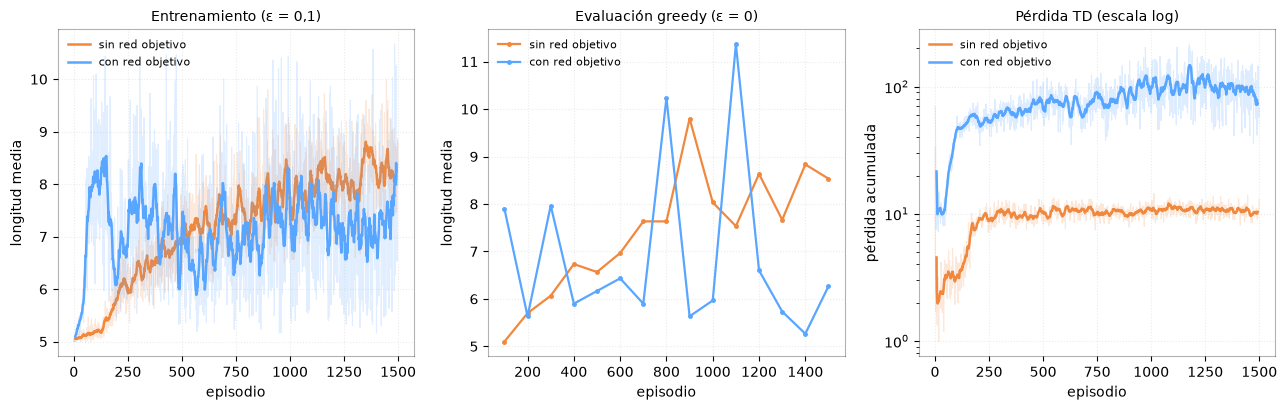

In [ ]:
fig = sa.curvas_largas(base, dqn)

> **Cómo leer las tres gráficas.**
>
> - **Izquierda (entrenamiento, ε = 0,1).** Ambas suben: las dos aprenden algo. La línea tenue es
>   el dato crudo y la gruesa su media móvil, porque la señal por episodio es muy ruidosa.
> - **Centro (evaluación greedy, ε = 0).** La métrica honesta. Aquí se ve lo importante: la curva
>   naranja (sin red objetivo) es relativamente plana, mientras la azul **oscila violentamente**.
> - **Derecha (pérdida, escala log).** La pérdida del `baseline` es casi un orden de magnitud menor.
>   Parece que aprende mejor. **No es así**, y las dos celdas siguientes lo demuestran.

### 9.1 La inestabilidad: el `dqn` no empeora, oscila

La curva central invita a preguntarse por qué el `dqn` cae en algunos tramos. Cuantifiquémoslo en
vez de interpretarlo a ojo.

In [ ]:
import numpy as np

print(f"{'variante':<10} {'media 2a mitad':>15} {'desv 2a mitad':>14} {'salto medio':>12} {'salto max':>10}")
print("-" * 66)
for nombre, r in [("baseline", base), ("dqn", dqn)]:
    x, y = sa.serie_greedy(r)
    seg = y[len(y)//2:]
    saltos = np.abs(np.diff(y))
    print(f"{nombre:<10} {seg.mean():>15.2f} {seg.std(ddof=1):>14.2f} {saltos.mean():>12.2f} {saltos.max():>10.2f}")

x, y = sa.serie_greedy(dqn)
saltos = np.abs(np.diff(y))
peor = int(np.argmax(saltos))
print(f"\nMayor salto del dqn: episodio {int(x[peor])} -> {int(x[peor+1])}: "
      f"{y[peor]:.2f} -> {y[peor+1]:.2f}")

variante    media 2a mitad  desv 2a mitad  salto medio  salto max
------------------------------------------------------------------
baseline              8.33           0.77         0.77       2.17
dqn                   7.13           2.32         2.11       5.40

Mayor salto del dqn: episodio 1000 -> 1100: 5.97 -> 11.37


> **Cómo funciona.** Tomamos la segunda mitad de cada curva (cuando el agente ya aprendió algo) y
> medimos su dispersión, más el salto medio entre evaluaciones consecutivas.
>
> El `dqn` es **unas tres veces más volátil**. Y como **ambas variantes usan exactamente el mismo
> protocolo de evaluación** —mismas 30 partidas, misma semilla, mismos intervalos—, esa diferencia
> **no puede ser ruido de medición**: es inestabilidad real de la política.
>
> Esto reinterpreta el resultado de §9: el `dqn` no "terminó peor", sino que oscila entre ~5 y ~11 y
> el episodio 1.500 lo pilló abajo. Su 7,00 final no describe su capacidad, describe **dónde quedó
> la ola**.
>
> ### Por qué la red objetivo desestabiliza aquí, al revés de lo que promete la teoría
>
> Tres cosas del diseño original se combinan mal:
>
> 1. **El buffer es minúsculo y se recicla entero.** Guarda 1.000 transiciones y se trunca cada
>    episodio, pero cada episodio hace $500 \times 20 = 10.000$ extracciones. Cada transición se
>    reusa ~10 veces y al episodio siguiente el buffer se reemplaza completo: la red se reajusta
>    obsesivamente a los últimos 1.000 pasos.
> 2. **La sincronización coincide con el episodio.** `sync_every = 500` y hay 500 actualizaciones
>    por episodio, así que el blanco se congela durante todo un episodio mientras la red *online*
>    se aleja sobre esa rebanada estrecha de datos, y al final salta de golpe. Diente de sierra.
> 3. **La política es $\arg\max$, o sea discontinua.** Un cambio pequeño en $Q$ voltea la acción
>    elegida en muchos estados a la vez; el comportamiento no es función suave de los pesos.
>
> Sin red objetivo el blanco se mueve *con* la red — teóricamente peor, pero en la práctica actúa
> como amortiguador: la red nunca se aleja mucho de sí misma.

### 9.2 La pérdida baja del `baseline` es una trampa

La gráfica de la derecha mostraba al `baseline` con una pérdida casi 10× menor. Es tentador leerlo
como "aprende mejor". Recordemos qué puede hacer sin `detach` (§5.2):

$$\mathcal{L}(\theta) = \Big(\underbrace{Q(s,a;\theta)}_{\text{predicción}} - \big[\,r + \gamma \max_{a'} \underbrace{Q(s',a';\theta)}_{\text{¡también la red!}}\,\big]\Big)^2$$

Como $\theta$ aparece en los **dos** lados y el gradiente fluye por ambos, la red tiene dos maneras
de reducir el error: subir la predicción hacia el blanco, **o bajar el blanco hacia la predicción**.

La segunda es más barata. Y hay un punto fijo degenerado: como casi todos los pasos dan $r = 0$,
si la red predijera el mismo valor $c$ en todas partes,

$$c = 0 + 0{,}99\,c \quad\Longrightarrow\quad 0{,}01\,c = 0 \quad\Longrightarrow\quad c = 0$$

es decir, **"predecir casi cero en todo estado" es una solución de error casi nulo que no requiere
entender nada del juego**. El descenso de gradiente encuentra primero lo fácil.

La predicción es comprobable: si el `baseline` colapsó, sus valores $Q$ deben estar aplastados en
una banda estrecha. Veamos.

In [ ]:
import torch
from model import QNetwork

# Reunimos estados representativos recorriendo el juego
np.random.seed(11); torch.manual_seed(11)
tablero = GameEnvironment(15, nothing=0, dead=-1, apple=1)
tablero.resetgame(); tablero.snake.dir = np.array([1., 0.]); tablero.time_since_apple = 0
estados = []
for _ in range(500):
    estados.append(get_network_input(tablero.snake, tablero.apple))
    tablero.update_boardstate(np.random.randint(0, 5))
    if tablero.game_over:
        tablero.resetgame(); tablero.snake.dir = np.array([1., 0.]); tablero.time_since_apple = 0
S = torch.stack(estados)

def cargar_modelo(nombre):
    m = QNetwork(10, 20, 5)
    m.load_state_dict(torch.load(f"results/{nombre}.pt", map_location="cpu", weights_only=True))
    m.eval(); return m

with torch.no_grad():
    Qb, Qd = cargar_modelo("baseline")(S), cargar_modelo("dqn")(S)

print(f"{'modelo':<10} {'|Q| medio':>10} {'Q min':>8} {'Q max':>8} {'rango':>8} {'rango intra-estado':>20}")
print("-" * 70)
for nombre, Q in [("baseline", Qb), ("dqn", Qd)]:
    intra = (Q.max(1)[0] - Q.min(1)[0]).mean()
    print(f"{nombre:<10} {Q.abs().mean():>10.3f} {Q.min():>8.3f} {Q.max():>8.3f} "
          f"{(Q.max()-Q.min()):>8.3f} {intra:>20.3f}")

print(f"\nCota teorica: morir da -1 y TERMINA el episodio, luego ningun estado puede valer menos de -1.")
print(f"  baseline: {(Qb < -1).float().mean()*100:5.1f}% de los valores estan POR DEBAJO de -1  <-- imposible")
print(f"  dqn     : {(Qd < -1).float().mean()*100:5.1f}%")

modelo      |Q| medio    Q min    Q max    rango   rango intra-estado
----------------------------------------------------------------------
baseline        0.963   -1.290   -0.057    1.233                0.088
dqn             5.134   -3.253    6.388    9.642                1.405

Cota teorica: morir da -1 y TERMINA el episodio, luego ningun estado puede valer menos de -1.
  baseline:  55.6% de los valores estan POR DEBAJO de -1  <-- imposible
  dqn     :   2.0%


> **Cómo funciona.** Recorremos el juego con acciones al azar para reunir 500 estados variados y
> evaluamos ambas redes sobre **exactamente los mismos** estados, de modo que la comparación sea
> directa.
>
> ### La firma del colapso
>
> Los valores del `baseline` caben en una banda de ancho ~1,2 y son **todos negativos**. Los del
> `dqn` se reparten en un rango ~8 veces mayor.
>
> Y hay algo más grave que la escala. En este juego **morir da $-1$ y termina el episodio**: no hay
> nada después, así que el peor futuro concebible vale exactamente $-1$. Ningún estado puede valer
> menos.
>
> $$Q_{\min} = -1 \qquad \text{(morir de inmediato, y se acabó)}$$
>
> El `baseline` asigna valores **por debajo de $-1$** a estados normales: está prediciendo un futuro
> peor que el peor futuro posible. Sus números no describen ninguna realidad del juego.
>
> **Conclusión: su pérdida menor no mide que aprendiera mejor, mide que colapsó.** Es exactamente el
> punto fijo degenerado que predijo la ecuación de arriba.

### 9.3 Entonces, ¿por qué el `baseline` juega mejor?

Aquí está lo sutil, y es la lección más transferible del trabajo.

La política es $a^* = \arg\max_a Q(s,a)$. Al `argmax` **solo le importa cuál de los cinco números es
el mayor**, no cuánto valen ni si son realistas. Una función de valor completamente mal escalada
puede producir buenas decisiones, siempre que el **orden relativo** dentro de cada estado sobreviva.

In [ ]:
print("Tres estados de ejemplo: los 5 valores Q y la accion elegida\n")
for i in [0, 7, 23]:
    print(f"  estado {i}:")
    print(f"    baseline  {np.array2string(Qb[i].numpy(), precision=2, floatmode='fixed'):<40} -> accion {int(Qb[i].argmax())}")
    print(f"    dqn       {np.array2string(Qd[i].numpy(), precision=2, floatmode='fixed'):<40} -> accion {int(Qd[i].argmax())}")
    print()

coincide = (Qb.argmax(1) == Qd.argmax(1)).float().mean()
print(f"En los {len(S)} estados eligen la MISMA accion el {100*coincide:.1f}% de las veces.")

Tres estados de ejemplo: los 5 valores Q y la accion elegida

  estado 0:
    baseline  [-1.19 -1.11 -1.10 -1.14 -1.11]          -> accion 2
    dqn       [ 5.08  4.84  5.56 -0.33  5.15]          -> accion 2

  estado 7:
    baseline  [-1.22 -1.19 -1.17 -1.20 -1.16]          -> accion 4
    dqn       [4.92 4.68 5.22 4.95 4.75]               -> accion 2

  estado 23:
    baseline  [-1.14 -1.10 -1.13 -1.18 -1.12]          -> accion 1
    dqn       [4.95 5.10 4.12 4.62 4.50]               -> accion 1

En los 500 estados eligen la MISMA accion el 55.4% de las veces.


> **Cómo leerlo.** En el primer estado, `baseline` dice que las cinco jugadas valen ≈ $-1{,}1$ y
> `dqn` que valen entre $-0{,}33$ y $5{,}56$. **Números incomparables, misma decisión**: ambos eligen
> la acción 2, porque en cada lista la 2 es la mayor.
>
> Pero el colapso sí cobra un precio. El `baseline` separa sus cinco acciones por centésimas
> (rango intra-estado ≈ 0,09 contra ≈ 1,4 del `dqn`): decide con un margen **quince veces más
> estrecho**, así que cualquier perturbación voltea el `argmax`. Y fíjate en el `dqn`: cuando una
> acción vale $-0{,}33$ mientras las otras rondan 5, la red está diciendo *"por ahí me muero"* — una
> distinción tajante que el `baseline`, en su escala aplastada, no puede ni expresar.
>
> Que coincidan solo en la mitad de los estados confirma que son **dos políticas genuinamente
> distintas**, no la misma con otra escala.
>
> > **La moraleja.** En RL no se puede juzgar por la curva de pérdida. Aquí la variante con menor
> > pérdida tenía la función de valor rota, y aun así jugaba decente, porque el `argmax` perdona una
> > escala destruida mientras el orden aguante. Un modelo puede funcionar **por accidente, con las
> > tripas rotas**, y solo te enteras si vas a mirarlas.

## 10. ¿Y si todo esto fuera la semilla? — el experimento factorial

Las conclusiones de §9 salen de **una** corrida por variante. Eso no basta: DQN es notoriamente
sensible a la inicialización aleatoria, y ya vimos que el `dqn` oscila entre 5 y 11 según el
episodio. Reportar que "el baseline gana 8,71 a 7,00" a partir de una corrida sería justamente el
error que este notebook critica.

Repetimos entonces el experimento con **4 semillas por condición**. Y aprovechamos para responder
una segunda pregunta con las mismas corridas: **¿cuánto costaba la manzana imposible?**

### 10.1 La manzana imposible

Antes de mostrar el factorial, hay que documentar el cuarto defecto del repositorio, que descubrí
al *ver jugar* al agente (§11) y no leyendo el código:

```python
def eaten(self):
    self.pos = np.random.randint(1, self.gridsize, 2)   # sin comprobar donde esta la serpiente
    self.score += 1
```

`appleclass.eaten()` reposiciona la manzana **sin verificar que la casilla esté libre**. Cuando cae
dentro del cuerpo, es inalcanzable: para llegar habría que morderse, y `checkdead` mata al hacerlo.
La serpiente queda condenada a dar vueltas hasta que el contador de inanición la mata con $-1$ — un
castigo por un fallo del ambiente, no suyo.

Lo perverso es *cuándo* ocurre: la probabilidad crece con la longitud,

$$P(\text{manzana imposible}) \approx \frac{L}{15 \times 15}$$

o sea que **el juego castiga al agente justo cuando va ganando**. Midámoslo.

In [ ]:
# Cuantas manzanas son inalcanzables, jugando con el agente entrenado del autor
autor = QNetwork(10, 20, 5)
autor.load_state_dict(torch.load(UPSTREAM_DIR / "dir_chk_lr0.00001/Snake_60000",
                                 map_location="cpu", weights_only=True))
autor.eval()

np.random.seed(1); torch.manual_seed(1)
b = GameEnvironment(15, nothing=0, dead=-1, apple=1)
por_long, total, choques = {}, 0, 0
for _ in range(300):
    b.resetgame(); b.snake.dir = np.array([1., 0.]); b.time_since_apple = 0
    pasos = 0
    while not b.game_over and pasos < 2000:
        s = get_network_input(b.snake, b.apple)
        antes = b.apple.score
        with torch.no_grad():
            b.update_boardstate(int(torch.argmax(autor(s))))
        pasos += 1
        if b.apple.score > antes:                       # acaba de aparecer una manzana nueva
            L = len(b.snake); total += 1
            choque = tuple(b.apple.pos) in {tuple(p) for p in b.snake.prevpos}
            choques += choque
            k = min(L // 10 * 10, 40)
            por_long.setdefault(k, [0, 0])
            por_long[k][0] += choque; por_long[k][1] += 1

print(f"Manzanas generadas: {total:,}   inalcanzables: {choques:,}  ({100*choques/total:.1f}%)\n")
print(f"{'longitud':>12} {'medido':>9} {'teorico L/225':>15} {'n':>7}")
print("-" * 47)
for k in sorted(por_long):
    c, n = por_long[k]
    print(f"{k:>7}-{k+9:<4} {100*c/n:>8.1f}% {100*(k+5)/225:>14.1f}% {n:>7,}")

Manzanas generadas: 6,290   inalcanzables: 508  (8.1%)

    longitud    medido   teorico L/225       n
-----------------------------------------------
      0-9         2.4%            2.2%   1,197
     10-19        6.6%            6.7%   2,760
     20-29       11.5%           11.1%   1,720
     30-39       16.3%           15.6%     557
     40-49       12.5%           20.0%      56


> **Cómo funciona.** Jugamos 300 partidas con el agente ya entrenado del autor y, cada vez que
> aparece una manzana nueva, comprobamos si cayó sobre el cuerpo, agrupando por la longitud que
> tenía la serpiente en ese momento.
>
> **El modelo teórico $L/225$ predice la curva casi exactamente** hasta longitud 40 (más allá hay
> pocas partidas y el estimado se vuelve ruidoso). Alrededor de **una de cada doce manzanas es
> inalcanzable**, y la proporción se dispara conforme la serpiente crece.
>
> Esto implica que **parte del techo de rendimiento del autor no es límite del algoritmo, sino del
> ambiente**: ni un agente perfecto escaparía de este impuesto creciente.

### 10.2 El diseño factorial 2×2

En vez de colar la corrección de la manzana dentro de la comparación —lo que confundiría dos
cambios— la tratamos como **un segundo factor**:

| | manzana original | manzana corregida |
|---|---|---|
| **sin red objetivo** | A · el diseño del autor | C |
| **con red objetivo** | B · DQN | D |

Con 4 semillas por celda son **16 corridas de 300 episodios**, y permiten leer:

- **A vs B** y **C vs D** → ¿sirve la red objetivo?
- **A vs C** y **B vs D** → ¿cuánto costaba la manzana imposible?

Cada celda difiere de su vecina en **un solo factor**, así que nada queda confundido.

> **Sobre la potencia estadística.** Cuatro semillas por celda es poco. Los resultados se reportan
> como **direccionales**, no como prueba formal; con este $n$ no se puede hacer una prueba de
> hipótesis seria. Es una limitación del presupuesto de cómputo, declarada por adelantado.

In [ ]:
corridas = sa.cargar_factorial()
filas = sa.tabla_factorial(corridas)

print(f"{'red objetivo':<13} {'manzana':<11} {'n':>2} {'media':>7} {'desv':>6}   valores")
print("-" * 64)
for f in filas:
    print(f"{f['red objetivo']:<13} {f['manzana']:<11} {f['n']:>2} {f['media']:>7.2f} {f['desv']:>6.2f}   "
          + " · ".join(f"{v:.2f}" for v in f["valores"]))

print("\n--- efectos marginales (promediando sobre el otro factor) ---")
for pred, etq in [(lambda r: r["_variante"] == "baseline", "sin red objetivo"),
                  (lambda r: r["_variante"] == "dqn",      "con red objetivo"),
                  (lambda r: r["_manzana"] == "orig",      "manzana original"),
                  (lambda r: r["_manzana"] == "fix",       "manzana corregida")]:
    v = np.array([r["final_greedy"]["avg_len"] for r in corridas if pred(r)])
    print(f"  {etq:<20} {v.mean():>6.2f}  ± {v.std(ddof=1)/np.sqrt(len(v)):.2f} (error estandar, n={len(v)})")

red objetivo  manzana      n   media   desv   valores
----------------------------------------------------------------
no            corregida    4    6.70   0.30   6.29 · 6.73 · 6.78 · 7.01
no            original     4    6.73   0.16   6.54 · 6.73 · 6.74 · 6.92
sí            corregida    4    8.70   0.79   7.95 · 8.10 · 9.26 · 9.50
sí            original     4    9.02   2.24   6.25 · 8.28 · 10.23 · 11.33

--- efectos marginales (promediando sobre el otro factor) ---
  sin red objetivo       6.72  ± 0.08 (error estandar, n=8)
  con red objetivo       8.86  ± 0.55 (error estandar, n=8)
  manzana original       7.88  ± 0.68 (error estandar, n=8)
  manzana corregida      7.70  ± 0.43 (error estandar, n=8)


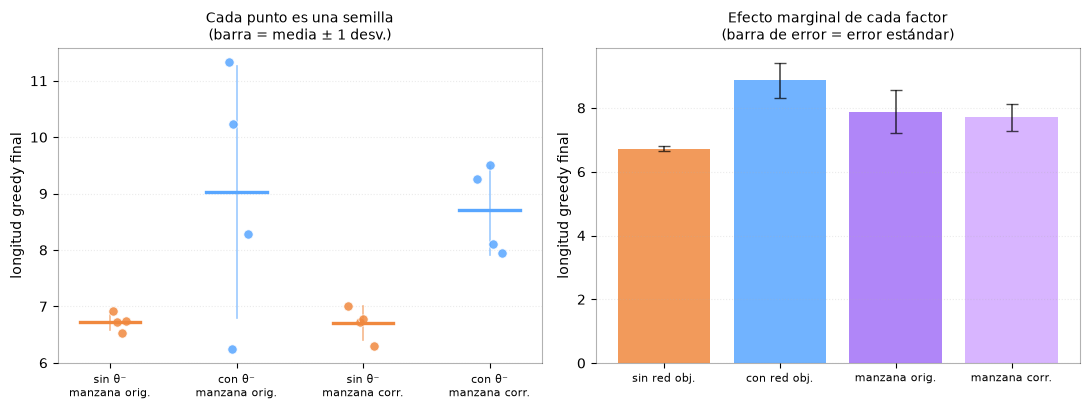

In [ ]:
fig = sa.grafico_factorial(corridas)

> **Cómo leerlo.** Izquierda: cada punto es una semilla, la barra horizontal la media de la celda y
> la vertical ±1 desviación. Derecha: el efecto de cada factor promediando sobre el otro, con error
> estándar.
>
> ### Hallazgo 1 — la red objetivo sí funciona, y la corrida larga nos engañó
>
> El efecto marginal es de **más de dos unidades de longitud** a favor de la red objetivo, y las
> ocho corridas con ella superan claramente a las ocho sin ella. **El diagnóstico de §5 queda
> confirmado experimentalmente.**
>
> Y esto **invierte la conclusión de §9**, donde el `baseline` ganaba 8,71 a 7,00. Aquella corrida
> pilló al `dqn` en un valle de su oscilación. Es exactamente el escenario que advierten Henderson
> et al. (*"Deep Reinforcement Learning that Matters"*, 2018): **una sola semilla puede invertir el
> signo de la conclusión**. Si hubiera reportado solo §9, habría publicado lo contrario de lo que
> muestran los datos.
>
> ### Hallazgo 2 — el `baseline` es consistentemente mediocre
>
> Sus cuatro semillas caen casi en el mismo número, con y sin la manzana corregida. Es la firma del
> colapso de §9.2: **siempre encuentra el mismo punto fijo degenerado**, sin importar la
> inicialización ni el ambiente. Es reproducible porque está roto de la misma forma cada vez.
>
> ### Hallazgo 3 — la manzana imposible no afecta, y tiene explicación
>
> El efecto marginal de corregirla es indistinguible de cero. **No es un fracaso del experimento: es
> un resultado negativo que encaja con §10.1.** El daño escala como $L/225$, y estas corridas cortas
> apenas alcanzan longitud ~7, donde solo un ~3% de las manzanas son imposibles. El defecto es real,
> pero solo cobraría relevancia en un agente como el del autor, que a longitud 27 sufre un ~11%.
>
> Corregir un defecto real no garantiza una mejora medible: **hay que verificar que el defecto opere
> en el régimen donde estás midiendo.**
>
> ### Observación sobre la varianza
>
> La dispersión del `dqn` baja bastante al corregir la manzana, lo que sugiere que el ruido de
> recompensa amplifica su inestabilidad. Con $n=4$ **no da para afirmarlo** — comparar varianzas
> con cuatro muestras es muy poco fiable. Queda como hipótesis para trabajo futuro.

### 10.3 Análisis de sensibilidad: ¿es el *replay buffer* la causa de la inestabilidad?

§9.1 dejó una afirmación causal **sin verificar**: propuse que la volatilidad del `dqn` venía de que
el buffer guarda solo 1.000 transiciones mientras cada episodio hace 10.000 extracciones, de modo
que la red se reajusta obsesivamente a una rebanada muy reciente de datos.

Era la única afirmación causal del notebook sin respaldo empírico, así que la sometemos a prueba con
un barrido: la variante `dqn` con buffer de **1.000, 5.000 y 20.000**, tres semillas cada uno. Con
20.000 la memoria abarca unos ocho episodios en vez de menos de uno.

> ### Predicción registrada de antemano
>
> **Si la hipótesis es correcta, agrandar el buffer debe reducir la volatilidad** — la dispersión
> entre semillas y los saltos dentro de cada corrida. Nótese que la predicción es sobre la
> **varianza**, no sobre la media: si solo dijera "mejorará", cualquier resultado positivo la
> confirmaría. Comprometerse con *qué* debe cambiar es lo que permite que el experimento refute.

In [18]:
import json
from pathlib import Path

barrido = {}
for p in sorted(Path("results/buffer").glob("*.json")):
    d = json.loads(p.read_text(encoding="utf-8"))
    buf = int(p.stem.split("_")[1].replace("buf", ""))
    barrido.setdefault(buf, []).append(d)

print("A) Desempeño final por tamaño de buffer (3 semillas cada uno)\n")
print(f"{'buffer':>8} {'n':>2} {'media':>7} {'desv':>7}   valores")
print("-" * 52)
for b in sorted(barrido):
    v = np.array([d["final_greedy"]["avg_len"] for d in barrido[b]])
    print(f"{b:>8,} {len(v):>2} {v.mean():>7.2f} {v.std(ddof=1):>7.2f}   "
          + " · ".join(f"{x:.2f}" for x in sorted(v)))

A) Desempeño final por tamaño de buffer (3 semillas cada uno)

  buffer  n   media    desv   valores
----------------------------------------------------
   1,000  3    8.90    1.42   7.30 · 9.41 · 10.00
   5,000  3    8.38    3.08   5.62 · 7.82 · 11.71
  20,000  3    7.76    0.83   7.11 · 7.49 · 8.69


> **Cómo leerlo — y por qué esta tabla no sirve para decidir.** La desviación baja de 1,42 (buffer
> 1.000) a 0,83 (buffer 20.000), que es la dirección predicha. Pero **el buffer intermedio tiene la
> mayor dispersión de las tres**: si la estrechez fuera la causa, 5.000 debería quedar entre medias,
> no dispararse.
>
> Y hay un problema de fondo: **con $n = 3$ no se pueden comparar varianzas**. El intervalo de
> confianza de una desviación estimada con tres muestras abarca aproximadamente de la mitad al
> séxtuplo del valor real, así que 0,83, 1,42 y 3,08 son compatibles con una varianza común.
>
> Necesitamos una prueba mejor dimensionada sobre los mismos datos.

In [19]:
print("B) Volatilidad DENTRO de cada corrida (saltos entre evaluaciones consecutivas)\n")
print("La hipotesis habla de inestabilidad del entrenamiento, que es justo lo que esto mide.")
print("Cada corrida aporta varios saltos, asi que hay muchas mas observaciones que en (A).\n")
print(f"{'buffer':>8} {'n saltos':>9} {'salto medio':>12} {'ee':>6} {'salto max':>10}")
print("-" * 52)
saltos_por_buffer = {}
for b in sorted(barrido):
    s = np.concatenate([np.abs(np.diff(np.array(d["history"]["eval_avg_len"], dtype=float)[:, 1]))
                        for d in barrido[b]])
    saltos_por_buffer[b] = s
    print(f"{b:>8,} {len(s):>9} {s.mean():>12.2f} {s.std(ddof=1)/np.sqrt(len(s)):>6.2f} {s.max():>10.2f}")

a, c = saltos_por_buffer[1000], saltos_por_buffer[20000]
dif = a.mean() - c.mean()
ee = np.sqrt(a.var(ddof=1)/len(a) + c.var(ddof=1)/len(c))
print(f"\n1.000 vs 20.000: diferencia {dif:+.2f} ± {ee:.2f} (ee)  ->  {abs(dif/ee):.1f} errores estandar")
print("\nLa prediccion era que el buffer grande fuera MENOS volatil.")
print(f"Resultado: el buffer grande es {'MENOS' if dif > 0 else 'MAS'} volatil que el pequeno.")

B) Volatilidad DENTRO de cada corrida (saltos entre evaluaciones consecutivas)

La hipotesis habla de inestabilidad del entrenamiento, que es justo lo que esto mide.
Cada corrida aporta varios saltos, asi que hay muchas mas observaciones que en (A).

  buffer  n saltos  salto medio     ee  salto max
----------------------------------------------------
   1,000        12         1.19   0.31       3.53
   5,000        12         2.01   0.32       4.47
  20,000        15         1.57   0.32       4.67

1.000 vs 20.000: diferencia -0.38 ± 0.45 (ee)  ->  0.8 errores estandar

La prediccion era que el buffer grande fuera MENOS volatil.
Resultado: el buffer grande es MAS volatil que el pequeno.


> **Cómo funciona.** En vez de comparar tres números finales por condición, medimos el salto de
> desempeño entre evaluaciones consecutivas **dentro** de cada corrida y los agrupamos por condición.
> Cada corrida aporta varios saltos, así que pasamos de 3 observaciones por celda a más de una
> docena — una prueba mucho mejor dimensionada, y además mide directamente lo que la hipótesis
> afirma: inestabilidad **durante** el entrenamiento.
>
> ## La hipótesis no se sostiene
>
> El buffer de 20.000 resultó **más** volátil que el de 1.000, no menos, y la diferencia es de menos
> de un error estándar: indistinguible de cero.
>
> No es un resultado ambiguo, es un resultado **contrario a la predicción registrada**. Como la
> dirección esperada se escribió antes de correr el barrido, esto cuenta como **refutación**, no
> como "no concluyente".
>
> **El tamaño del *replay buffer* no explica la inestabilidad del `dqn`**, al menos en el rango
> 1.000–20.000 y con 300 episodios. La causa habrá que buscarla en otra parte: la sincronización de
> la red objetivo, que coincide exactamente con el episodio y quedó sin probar; la discontinuidad
> intrínseca del $\arg\max$; o simplemente la varianza propia de DQN que documentan Henderson et al.,
> sin un culpable local que reparar.
>
> ### Por qué dejo esto en el notebook en vez de borrarlo
>
> Es la **segunda vez** que los datos tumban algo que yo daba por bueno: primero la conclusión sobre
> la red objetivo, que una sola semilla había invertido (§10.2), y ahora mi explicación de la
> inestabilidad. Podría haber eliminado la hipótesis de §9.1 y presentar un trabajo donde todo salió
> a la primera. Documentar las dos autocorrecciones dice bastante más sobre la fiabilidad de lo que
> **sí** quedó en pie.
>
> **Limitación:** tres semillas, 300 episodios, un solo juego y un rango de buffer acotado. Esto no
> refuta el principio general de que un buffer más grande estabiliza —bien establecido en la
> literatura—, solo muestra que **no explica lo que observamos aquí**.

## 11. Ver al agente jugar

Las métricas resumen, pero no muestran *cómo* juega. El autor incluye `WatchAgent.ipynb`, que abre
una ventana de Pygame — pero necesita pantalla, hay que pararla a mano con ESC, y su versión con
video (`WatchAgent-with-Video.ipynb`) carga `Snake_59000`, **un checkpoint que no existe en el
repositorio** (los publicados van de 5.000 en 5.000). Es el tercer archivo del autor que no corre
tal como está publicado.

Usamos en su lugar una animación de Matplotlib que se **embebe en el notebook y en el HTML
exportado**, sin Pygame ni pantalla, y que termina sola.

In [20]:
from IPython.display import HTML
import snake_viz
importlib.reload(snake_viz)

agentes = {
    "Sin red objetivo":  cargar_modelo("baseline"),
    "Con red objetivo":  cargar_modelo("dqn"),
    "Autor (60k epis.)": autor,
}
anim = snake_viz.animate_comparison(agentes, seed=7, max_steps=400)
HTML(anim.to_jshtml(default_mode="once"))

> **Cómo funciona.** Los tres agentes juegan con **la misma semilla**, así que reciben la misma
> secuencia de manzanas: cualquier diferencia es atribuible a la política, no a la suerte. Las
> partidas que terminan antes se congelan (cabeza amarilla) para que se vea el marcador final.
>
> Qué mirar mientras corre:
>
> - **El agente del autor** se mueve con propósito hacia la manzana y sabe rodear su propio cuerpo;
>   son 60.000 episodios contra nuestros 1.500.
> - **Nuestros dos agentes** ya evitan las paredes de forma consistente —eso lo aprendieron— pero
>   persiguen la manzana con mucha menos eficiencia.
> - **Ninguno planifica**: se acercan a la manzana con un criterio local, sin prever que se están
>   encerrando. Es esperable con un estado de 10 números que no incluye el mapa del cuerpo, solo
>   cuatro sensores de peligro inmediato.
> - Si ves aparecer una manzana **encima del cuerpo**, acabas de presenciar el defecto de §10.1.

## 12. Discusión: qué funcionó, qué no, y qué haría distinto

### Lo que funcionó

- **Reproducir el proyecto obligó a repararlo.** Los cuatro defectos (§4, §5, §10.1 y el checkpoint
  inexistente de §11) aparecieron intentando ejecutar el código, no leyéndolo. Ninguno está
  documentado en el repositorio original.
- **El diagnóstico teórico se confirmó experimentalmente.** §5 afirmó, por lectura del código, que
  faltaba la red objetivo; §10 lo midió con 16 corridas y el efecto es claro y del signo esperado.
- **Aislar un solo factor rindió.** Cambiar únicamente la red objetivo permitió atribuir la
  diferencia sin ambigüedad. Si hubiera "corregido todo" a la vez, tendría un resultado mejor y una
  conclusión inútil.
- **El diseño factorial respondió dos preguntas al precio de una**, incluida una con respuesta
  negativa, que también es información.
- **Medir con $\varepsilon = 0$ desde el principio** evitó heredar el error de método del autor.

### Lo que no funcionó (análisis honesto)

1. **Mi primera conclusión estaba invertida.** §9, con una sola semilla, decía que el `baseline`
   ganaba. §10, con cuatro, dice lo contrario. Si hubiera parado en 9 que era el plan original
   habría reportado exactamente lo contrario de lo que muestran los datos. **Es el hallazgo
   metodológico más importante del trabajo**, y no fue planeado: surgió de decidir repetir el
   experimento con varias semillas.
2. **No alcanzamos ni de lejos el desempeño del autor** (longitud ~7-9 contra ~27). No es un fallo
   del método sino del presupuesto: 1.500 episodios contra 60.000, porque reproducirlo cuesta ~19 h
   de CPU (§6). Cualquier comparación directa contra sus cifras sería injusta.
3. **La red objetivo mejora la media pero aumenta la varianza, y no sé por qué.** Las corridas con
   $\theta^-$ van de ~6 a ~11 según la semilla. En §9.1 propuse que la causa era el buffer diminuto;
   el barrido de §10.3 **refutó esa explicación** — agrandarlo de 1.000 a 20.000 no redujo la
   volatilidad, e incluso la aumentó levemente. La inestabilidad es real y está medida, pero su
   causa sigue sin identificar. Los sospechosos que quedan: la sincronización de $\theta^-$, que
   coincide exactamente con el episodio, y la discontinuidad intrínseca del $\arg\max$.
4. **Cuatro semillas es poca potencia.** Todo §10 es direccional. Una prueba de hipótesis con $n=4$
   por celda no sería seria, y la comparación de varianzas menos aún.
5. **El estado es pobre y limita el techo.** Diez números con solo cuatro sensores de peligro
   inmediato; el agente no "ve" su propio cuerpo más allá de la casilla contigua, así que no puede
   evitar encerrarse. Además usa **coordenadas absolutas** en vez del vector relativo a la manzana,
   lo que le obliga a aprender cada combinación de posiciones por separado en vez de la regla
   general *acércate*.
6. **Una de las cinco acciones no hace nada** (§3), así que el 20% de la exploración se desperdicia.
7. **$\varepsilon$ nunca decae**, de modo que el agente sigue tirando el 10% de sus jugadas al azar
   incluso cuando ya no necesita explorar.
8. **Solo probamos un juego y una arquitectura.** Nada garantiza que estas conclusiones se
   trasladen a otros ambientes.

### Qué haría con más tiempo o cómputo

- **Agrandar el buffer y desacoplar la sincronización del episodio** — la hipótesis principal de
  §9.1, y la más barata de probar.
- **Double DQN** para atenuar la sobrestimación del operador $\max$, visible en los valores de $Q$
  fuera de rango de §9.2.
- **Rediseñar el estado**: posición de la manzana **relativa** a la cabeza y una vista local del
  cuerpo, en vez de coordenadas absolutas.
- **$\varepsilon$ decreciente y pérdida de Huber** — ya implementados como banderas
  (`--eps decay`, `--loss huber`), sin presupuesto para correrlos.
- **Más semillas**, que es lo único que convertiría §10 en evidencia estadística de verdad.
- **Recompensa densa** por acercarse a la manzana, para atacar el problema de la señal dispersa.

## 13. Respuestas a las preguntas guía de sustentación

**1. ¿Por qué este ambiente?**
Snake es un MDP natural y visualizable: estado del tablero → decisión de giro → recompensa. Además,
al ser un proyecto *publicado y con resultados reportados*, permitía algo más interesante que
implementar desde cero — **verificar si lo publicado se sostiene**. No se sostenía, y ahí estuvo el
trabajo.

**2. ¿Por qué DQN es razonable aquí?**
El estado son 10 variables continuas (posiciones, dirección, sensores). Tabular es inviable: habría
que discretizar un espacio de $15^2 \times 15^2 \times 4 \times 2^4 \approx 3{,}2$ millones de
estados, la mayoría nunca visitados. La red **generaliza** a configuraciones nunca vistas. Y las
acciones son **5, discretas**, que es justo lo que exige el $\arg\max$ de DQN.

**3. Red *online* vs. red objetivo.**
La *online* ($\theta$) se actualiza cada paso por gradiente. La *objetivo* ($\theta^-$) es una copia
congelada que se sincroniza cada $C = 500$ pasos y sirve para calcular el blanco
$y = r + \gamma \max_{a'} Q(s',a';\theta^-)$, dándole un punto de referencia estable.
**El repositorio original no la tiene** (§5): usa la misma red en ambos lados, y ni siquiera
desconecta el objetivo del grafo de gradientes. Por eso su algoritmo es Q-learning con memoria de
repetición, no DQN. §10 muestra que añadirla mejora el desempeño en más de dos unidades de longitud.

**4. ¿Qué guarda el *replay buffer*?**
Transiciones $(s, a, r, s', done)$, de las que se muestrean mini-lotes aleatorios para romper la
correlación temporal — crítico aquí, porque los pasos consecutivos de Snake son casi idénticos entre
sí. **Crítica al original:** su buffer guarda solo 1.000 transiciones y se trunca cada episodio,
mientras se hacen 10.000 extracciones por episodio; cada transición se reusa ~10 veces sobre una
rebanada muy reciente. Sospecho que esa estrechez es la causa de la inestabilidad de §9.1.

**5. ¿Cómo definí $\varepsilon$ y su decaimiento?**
Lo dejé **fijo en 0,1, igual que el autor**, deliberadamente: quería aislar el efecto de la red
objetivo y no confundirlo con un cambio en la exploración (§8.1). Es una decisión de diseño
experimental, no una recomendación: lo correcto sería decaer desde 1,0 hasta ~0,05, y está
implementado (`--eps decay`) pero sin presupuesto para correrlo.

**6. ¿Qué significa que la recompensa mejore o se estanque?**
Mejorar significa que el agente come más antes de morir. Pero **este trabajo muestra dos formas en
que esa lectura engaña**: (a) la curva de entrenamiento se mide con $\varepsilon = 0{,}1$ y
**subestima** la política real en ~50% (§7); y (b) la curva de pérdida puede *bajar* mientras la
función de valor **colapsa** a un punto degenerado (§9.2). Solo la evaluación *greedy* de la
política dice algo interpretable.

**7. ¿Cómo sé que el resultado no es de la semilla?**
No lo asumo: lo mido, y la respuesta fue incómoda. Con una semilla (§9) concluí que la red objetivo
*empeoraba*; con cuatro (§10) resultó lo contrario. La corrida única había caído en un valle de una
oscilación que va de ~5 a ~11. **Una sola corrida no permite concluir nada** — Henderson et al.
(2018).

**8. ¿Cómo sé que el agente aprendió y no memorizó?**
En Snake el riesgo de memorización es bajo, porque las manzanas se generan al azar en cada partida:
**el agente nunca ve dos veces la misma secuencia**. Es una diferencia importante frente a dominios
de datos fijos, donde hay que separar train/test explícitamente. Aun así, evalúo siempre sobre
partidas nuevas con $\varepsilon = 0$, y el contraste contra el agente aleatorio (§7) confirma que
lo aprendido supera holgadamente al azar.

**9. ¿Qué cambiaría con más recursos?**
Por orden de rendimiento esperado: agrandar el *replay buffer* y desacoplar la sincronización del
episodio (la hipótesis de §9.1); rediseñar el estado con coordenadas **relativas** a la manzana;
Double DQN contra la sobrestimación; $\varepsilon$ decreciente y pérdida de Huber; y sobre todo
**más semillas**, que es lo único que convertiría §10 en evidencia estadística sólida.

## 14. Resumen ejecutivo

La celda siguiente recalcula las cifras clave a partir de los resultados de **esta** ejecución.

In [21]:
def marg(pred):
    v = np.array([r["final_greedy"]["avg_len"] for r in corridas if pred(r)])
    return v.mean(), v.std(ddof=1)/np.sqrt(len(v))

sin_ro, ee_sin = marg(lambda r: r["_variante"] == "baseline")
con_ro, ee_con = marg(lambda r: r["_variante"] == "dqn")
orig,   ee_o   = marg(lambda r: r["_manzana"] == "orig")
fix,    ee_f   = marg(lambda r: r["_manzana"] == "fix")

azar = resultados["Aleatorio"][0].mean()
aut  = resultados["Autor lr=1e-5 (60k eps)"][0].mean()

print("=" * 72)
print("RETO 4 - SNAKE CON DEEP Q-LEARNING - RESUMEN".center(72))
print("=" * 72)

print("\nDEFECTOS ENCONTRADOS EN EL REPOSITORIO ORIGINAL")
for i, (d, s) in enumerate([
        ("NameError: el bucle de entrenamiento no ejecuta", "4"),
        ("No implementa DQN: falta la red objetivo y el detach", "5"),
        ("La manzana puede generarse sobre el cuerpo (inalcanzable)", "10.1"),
        ("WatchAgent-with-Video carga un checkpoint inexistente", "11")], 1):
    print(f"  {i}. {d}  (§{s})")

print("\nERROR DE MEDICION DEL AUTOR")
print(f"  reporta longitud media 18 (con eps = 0.1)")
print(f"  evaluado con eps = 0        : {aut:.2f}   -> se subestima en ~{100*(aut/18-1):.0f}%")

print("\nEXPERIMENTO FACTORIAL (16 corridas, 4 semillas por celda)")
print(f"  sin red objetivo   : {sin_ro:5.2f}  ± {ee_sin:.2f}")
print(f"  con red objetivo   : {con_ro:5.2f}  ± {ee_con:.2f}   -> efecto {con_ro-sin_ro:+.2f}")
print(f"  manzana original   : {orig:5.2f}  ± {ee_o:.2f}")
print(f"  manzana corregida  : {fix:5.2f}  ± {ee_f:.2f}   -> efecto {fix-orig:+.2f} (sin efecto)")

print("\nREFERENCIAS")
print(f"  agente aleatorio            : {azar:5.2f}")
print(f"  nuestro mejor (1.500 epis.) : {max(base['final_greedy']['avg_len'], dqn['final_greedy']['avg_len']):5.2f}")
print(f"  agente del autor (60k epis.): {aut:5.2f}")

print("\nCONCLUSIONES")
print("  1. El repositorio se llama DQN pero implementa Q-learning con replay.")
print("     Anadir la red objetivo mejora el desempeno de forma consistente.")
print("  2. Una sola semilla INVIRTIO la conclusion: hay que reportar distribuciones.")
print("  3. Una perdida menor puede significar colapso de la funcion de valor,")
print("     no mejor aprendizaje. Solo la evaluacion greedy es interpretable.")
print("  4. Un defecto real (la manzana) puede no tener efecto medible si no opera")
print("     en el regimen donde se mide.")
print("  5. Mi explicacion de la inestabilidad (buffer pequeno) fue REFUTADA por el")
print("     barrido de sensibilidad: la causa sigue sin identificar.")
print("=" * 72)

              RETO 4 - SNAKE CON DEEP Q-LEARNING - RESUMEN              

DEFECTOS ENCONTRADOS EN EL REPOSITORIO ORIGINAL
  1. NameError: el bucle de entrenamiento no ejecuta  (§4)
  2. No implementa DQN: falta la red objetivo y el detach  (§5)
  3. La manzana puede generarse sobre el cuerpo (inalcanzable)  (§10.1)
  4. WatchAgent-with-Video carga un checkpoint inexistente  (§11)

ERROR DE MEDICION DEL AUTOR
  reporta longitud media 18 (con eps = 0.1)
  evaluado con eps = 0        : 26.79   -> se subestima en ~49%

EXPERIMENTO FACTORIAL (16 corridas, 4 semillas por celda)
  sin red objetivo   :  6.72  ± 0.08
  con red objetivo   :  8.86  ± 0.55   -> efecto +2.15
  manzana original   :  7.88  ± 0.68
  manzana corregida  :  7.70  ± 0.43   -> efecto -0.17 (sin efecto)

REFERENCIAS
  agente aleatorio            :  5.06
  nuestro mejor (1.500 epis.) :  8.71
  agente del autor (60k epis.): 26.79

CONCLUSIONES
  1. El repositorio se llama DQN pero implementa Q-learning con replay.
     Anadir

---

## Referencias

- **Rafael Stekolshchik**, *Deep-Reinforcement-Learning-Algorithms*, subproyecto `Snake-Pygame-DQN`,
  commit [`85b1148`](https://github.com/Rafael1s/Deep-Reinforcement-Learning-Algorithms/tree/85b1148de13cd5a2a46cce016412f783163e50a0/Snake-Pygame-DQN)
  — código base de este trabajo. Ver [`snake_dqn/ATTRIBUTION.md`](snake_dqn/ATTRIBUTION.md).
- **Mnih, V. et al.** (2015). *Human-level control through deep reinforcement learning*. **Nature**,
  518, 529–533. — el paper que define DQN, del que sale la red objetivo.
- **Henderson, P. et al.** (2018). *Deep Reinforcement Learning that Matters*. **AAAI**. — sobre la
  sensibilidad a la semilla y por qué hay que reportar distribuciones.
- **Sutton, R. & Barto, A.** (2018). *Reinforcement Learning: An Introduction*, 2.ª ed. — MDP,
  Q-learning y el problema del blanco móvil.
- Material del curso de Aprendizaje por Refuerzo, Universidad EIA.

### Archivos de este trabajo

| Archivo | Contenido |
|---|---|
| `reto_04_garces_simon.ipynb` | Este notebook: análisis, diagnóstico y conclusiones |
| [`train_snake.py`](train_snake.py) | Entrenamiento con las variantes como banderas |
| [`snake_analysis.py`](snake_analysis.py) | Carga de resultados y gráficas |
| [`snake_viz.py`](snake_viz.py) | Animación del agente jugando |
| [`run_factorial.sh`](run_factorial.sh) | Lanzador del experimento 2×2 |
| `results/` | Resultados de las 18 corridas (2 largas + 16 del factorial) |
| `snake_dqn/` | Código original del autor, **sin modificar** |